# ARTIQ on RISC-Q: send, receive, verify

The experiment below is written EXACTLY as an ARTIQ experiment — `EnvExperiment`,
`build`/`run`/`analyze`, `setattr_device`, `@kernel`, bare `with parallel:` /
`with sequential:` and bare `delay()` — with RISC-Q's own kernel compiler underneath
(`riscq.artiq_compat`). It runs LIVE on the RFSoC 4x2: the sequence is the two-pulse waveform
of `reference/waveform_generator.py`, the ADC is read back in `analyze()`, and the capture is
overlaid on the generator point by point.

In [1]:
import sys
sys.path[:0] = ["../client", "../../sim"]      # riscq (client) + riscq_sim (co-sim)
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.dpi"] = 110

from riscq.artiq_compat import *


class IonTrap(EnvExperiment):
    def build(self):
        self.setattr_device("core")
        self.setattr_device("gate_dds")
        self.setattr_device("ro_dds")
        self.setattr_device("adc")

    @kernel
    def run(self):
        self.core.reset()
        with parallel:
            with sequential:                            # send: the two-pulse sequence
                with parallel:
                    with sequential:
                        self.gate_dds.set(83.765*MHz, phase=0.0, amplitude=0.4)
                        self.gate_dds.sw.pulse(100*us)
                    with sequential:
                        self.ro_dds.set(80.235*MHz, phase=0.5, amplitude=0.4)
                        self.ro_dds.sw.pulse(100*us)
                delay(5*us)
                self.ro_dds.set(82.0*MHz, phase=0.25, amplitude=0.4,
                                phase_mode=PHASE_MODE_ABSOLUTE)
                self.ro_dds.sw.pulse(20*us)
            with sequential:                            # receive: record while it plays
                self.adc.gate(125*us)

    def analyze(self):
        self.trace = self.adc.fetch_trace()             # <- the raw ADC samples

In [2]:
device_db = {
    "core":     {"type": "board", "host": "192.168.3.1", "bundle": "rfsoc4x2-1q-fine"},
    "gate_dds": {"type": "dds", "channel": 0},
    "ro_dds":   {"type": "dds", "channel": 1},
    "adc":      {"type": "adc"},
}

exp = run_experiment(IonTrap, device_db)                # the artiq_run role, live
x, fs = exp.trace.astype(float), exp.last_result.fs
x -= x[:300].mean()                                     # remove the ADC's small DC offset
t = np.arange(x.size) / fs
print(f"{x.size} ADC samples at {fs/1e9:.5f} GS/s = {x.size/fs*1e6:.1f} us")

245760 ADC samples at 1.96608 GS/s = 125.0 us


delay D = 186.828 ns, scale = 5974 code/unit
in-pulse: signal rms 5737 code, residual rms 25 code (0.43 %)
carrier phase, capture vs generator @ 83.765 MHz: -0.09 deg
carrier phase, capture vs generator @ 80.235 MHz: +0.11 deg
carrier phase, capture vs generator @ 82.000 MHz: -0.00 deg


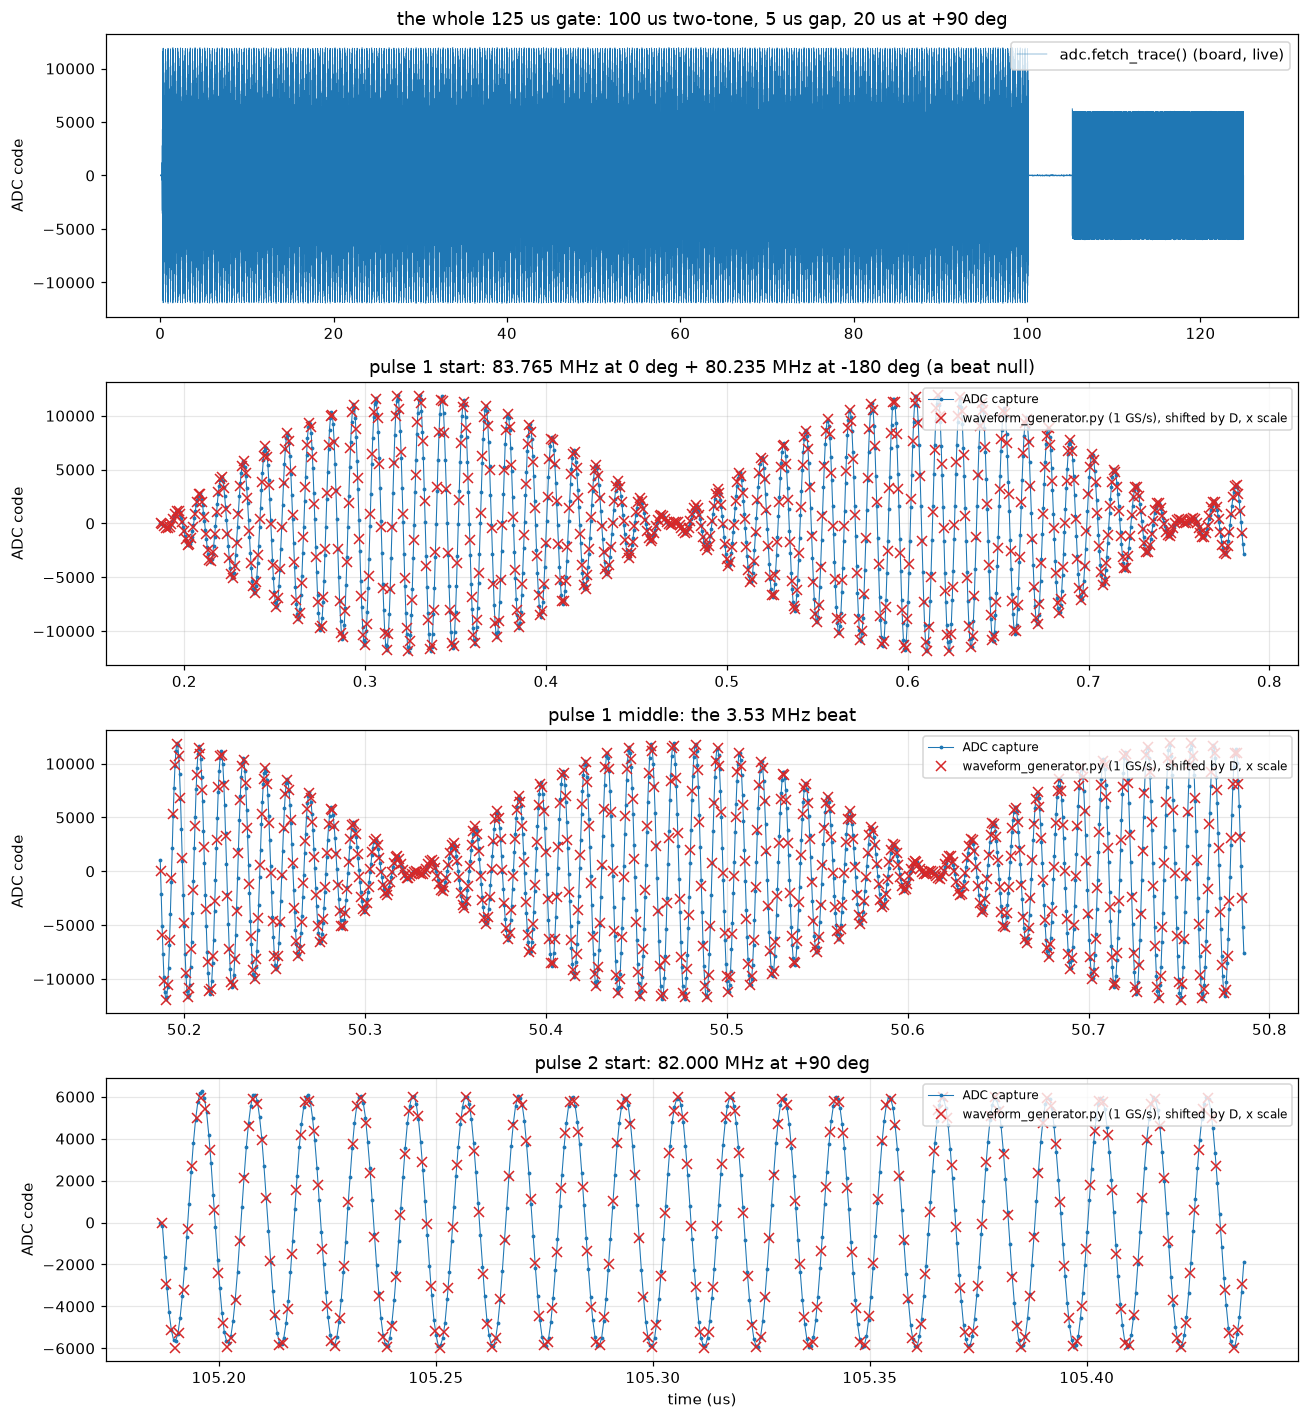

In [3]:
# overlay the capture on reference/waveform_generator.py's waveform
orig = np.load("reference/waveform.npz")                 # the generator at 1 GS/s
t_o, w_o = orig["time_us"] * 1e-6, orig["waveform"]

def phi(sig, tt, f, lo_s, hi_s):                     # tone phase over a window
    r = 1.0 / (tt[1] - tt[0])
    sl = slice(int(lo_s * r), int(hi_s * r))
    return np.angle(np.sum(sig[sl] * np.exp(-2j*np.pi*f*tt[sl])))

pad = 262500                                         # 1 GS/s -> fs lands on integers
W = np.fft.rfft(np.concatenate((w_o, np.zeros(pad - w_o.size))))
f_ax = np.fft.rfftfreq(pad, 1e-9)
n2 = round(pad * fs / 1e9)
def resample(D):                                     # the generator on the ADC grid, delayed by D
    R2 = np.zeros(n2 // 2 + 1, complex)
    R2[:W.size] = W * np.exp(-2j * np.pi * f_ax * D)
    return (np.fft.irfft(R2, n2) * (n2 / pad))[:x.size]

# end-to-end delay: the 82 MHz phase in pulse 2 fixes D modulo one carrier cycle;
# the residual picks the cycle (pulse 1 starts on a beat null, so the onset alone cannot)
f2, on = 82e6, np.argmax(np.abs(x) > max(6 * x[:300].std(), 0.05 * np.abs(x).max()))
Df = (t[on] + ((phi(w_o, t_o, f2, 106e-6, 118e-6) - phi(x, t, f2, 106e-6, 118e-6))
               / (2*np.pi*f2) - t[on] + 0.5/f2) % (1/f2)) - 0.5/f2
best = None
for k in range(-6, 7):
    Dk = Df + k / f2
    r = resample(Dk)
    sl = slice(int((40e-6 + Dk)*fs), int((60e-6 + Dk)*fs))
    sc = np.dot(x[sl], r[sl]) / np.dot(r[sl], r[sl])
    rms = np.sqrt(np.mean((x[sl] - sc * r[sl])**2))
    if best is None or rms < best[0]:
        best = (rms, Dk, sc)
_, D, scale = best
ref = scale * resample(D)

inp = np.r_[int((1e-6+D)*fs):int((99e-6+D)*fs), int((106e-6+D)*fs):int((124e-6+D)*fs)]
print(f"delay D = {D*1e9:.3f} ns, scale = {scale:.0f} code/unit")
print(f"in-pulse: signal rms {np.sqrt(np.mean(x[inp]**2)):.0f} code, residual rms "
      f"{np.sqrt(np.mean((x-ref)[inp]**2)):.0f} code "
      f"({100*np.sqrt(np.mean((x-ref)[inp]**2)/np.mean(x[inp]**2)):.2f} %)")
for name, f0, lo, hi in (("83.765", 83.765e6, 2e-6, 98e-6), ("80.235", 80.235e6, 2e-6, 98e-6),
                         ("82.000", 82.0e6, 106e-6, 118e-6)):
    d = np.degrees(((phi(x, t, f0, lo+D, hi+D) - phi(ref, t, f0, lo+D, hi+D) + np.pi)
                    % (2*np.pi)) - np.pi)
    print(f"carrier phase, capture vs generator @ {name} MHz: {d:+.2f} deg")

fig, ax = plt.subplots(4, 1, figsize=(12, 13))
ax[0].plot(t*1e6, x, lw=0.3, color="C0", label="adc.fetch_trace() (board, live)")
ax[0].set_title("the whole 125 us gate: 100 us two-tone, 5 us gap, 20 us at +90 deg")
ax[0].set_ylabel("ADC code"); ax[0].legend(loc="upper right")
for a, (t0, w, title) in zip(ax[1:], (
        (0.0, 0.6, "pulse 1 start: 83.765 MHz at 0 deg + 80.235 MHz at -180 deg (a beat null)"),
        (50.0, 0.6, "pulse 1 middle: the 3.53 MHz beat"),
        (105.0, 0.25, "pulse 2 start: 82.000 MHz at +90 deg"))):
    sl = slice(int((t0*1e-6 + D)*fs), int(((t0+w)*1e-6 + D)*fs))
    a.plot(t[sl]*1e6, x[sl], ".-", ms=3, lw=0.7, color="C0", label="ADC capture")
    mm = (t_o + D >= t[sl][0]) & (t_o + D <= t[sl][-1])
    a.plot((t_o[mm] + D)*1e6, scale*w_o[mm], "x", ms=6, color="C3",
           label="waveform_generator.py (1 GS/s), shifted by D, x scale")
    a.set_title(title); a.set_ylabel("ADC code"); a.legend(loc="upper right", fontsize=8)
    a.grid(alpha=0.3)
ax[-1].set_xlabel("time (us)")
plt.tight_layout(); plt.show()